# 🏠 Predicting House Prices with Linear Regression
### Oasis Infobyte Internship — Data Analytics | Level 2, Task 1
**Name:** Param Parag Koli
**Batch:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1 — Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv('/content/Housing.csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nDescriptive Statistics:")
df.describe()

Shape: (545, 13)

Column Names: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data Types:
 price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Null Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Descriptive Statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 📊 Step 2 — Distribution of Target Variable (Price)

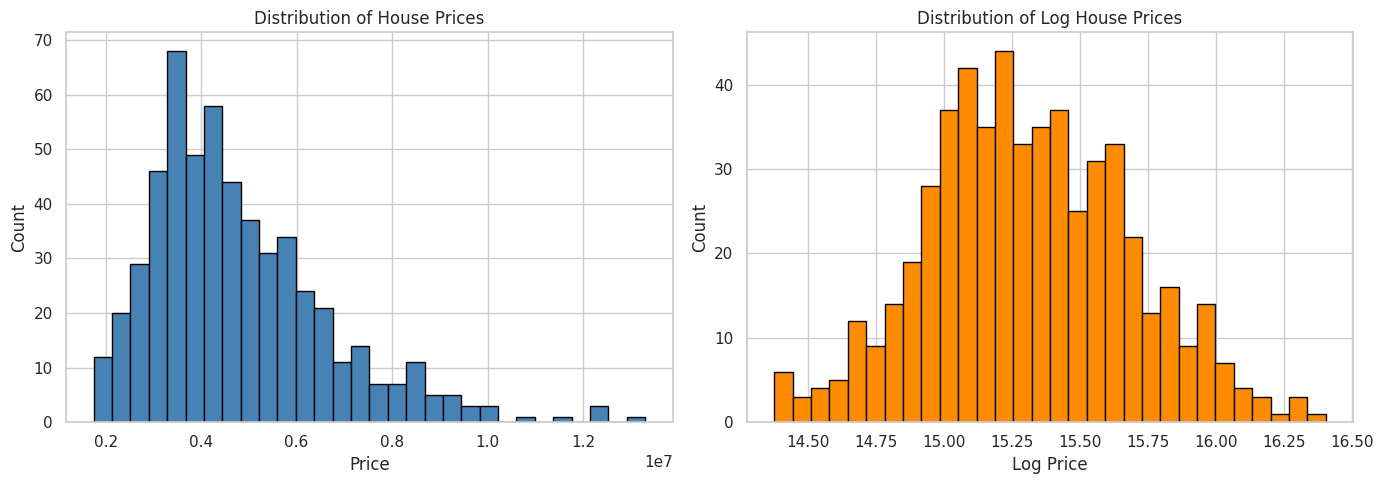

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of House Prices')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=30, color='darkorange', edgecolor='black')
axes[1].set_title('Distribution of Log House Prices')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 🔢 Step 3 — Encode Categorical Features

In [4]:
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded:", categorical_cols)
df.head()

Categorical columns encoded: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


## 🔥 Step 4 — Correlation Heatmap

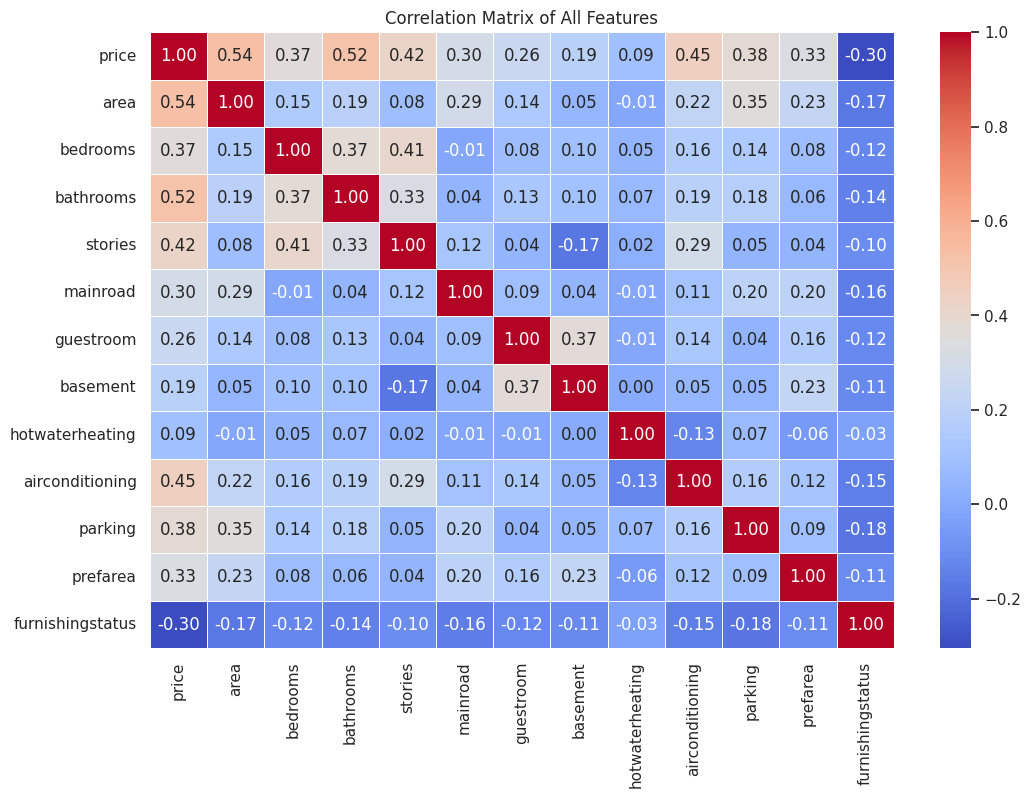

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.show()

## ✂️ Step 5 — Train/Test Split

In [6]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (436, 12)
Testing set size: (109, 12)


## 🤖 Step 6 — Train Linear Regression Model

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print("MSE:", round(lr_mse, 2))
print("RMSE:", round(lr_rmse, 2))
print("R² Score:", round(lr_r2, 4))

Linear Regression Results:
MSE: 1771751116594.04
RMSE: 1331071.42
R² Score: 0.6495


## 🤖 Step 7 — Train Ridge & Lasso Models

In [8]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

print("Ridge Regression Results:")
print("MSE:", round(mean_squared_error(y_test, ridge_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, ridge_pred)), 2))
print("R² Score:", round(r2_score(y_test, ridge_pred), 4))

print("\nLasso Regression Results:")
print("MSE:", round(mean_squared_error(y_test, lasso_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lasso_pred)), 2))
print("R² Score:", round(r2_score(y_test, lasso_pred), 4))

Ridge Regression Results:
MSE: 1774225918472.88
RMSE: 1332000.72
R² Score: 0.649

Lasso Regression Results:
MSE: 1771754686404.36
RMSE: 1331072.76
R² Score: 0.6495


## 📊 Step 8 — Actual vs Predicted Plot

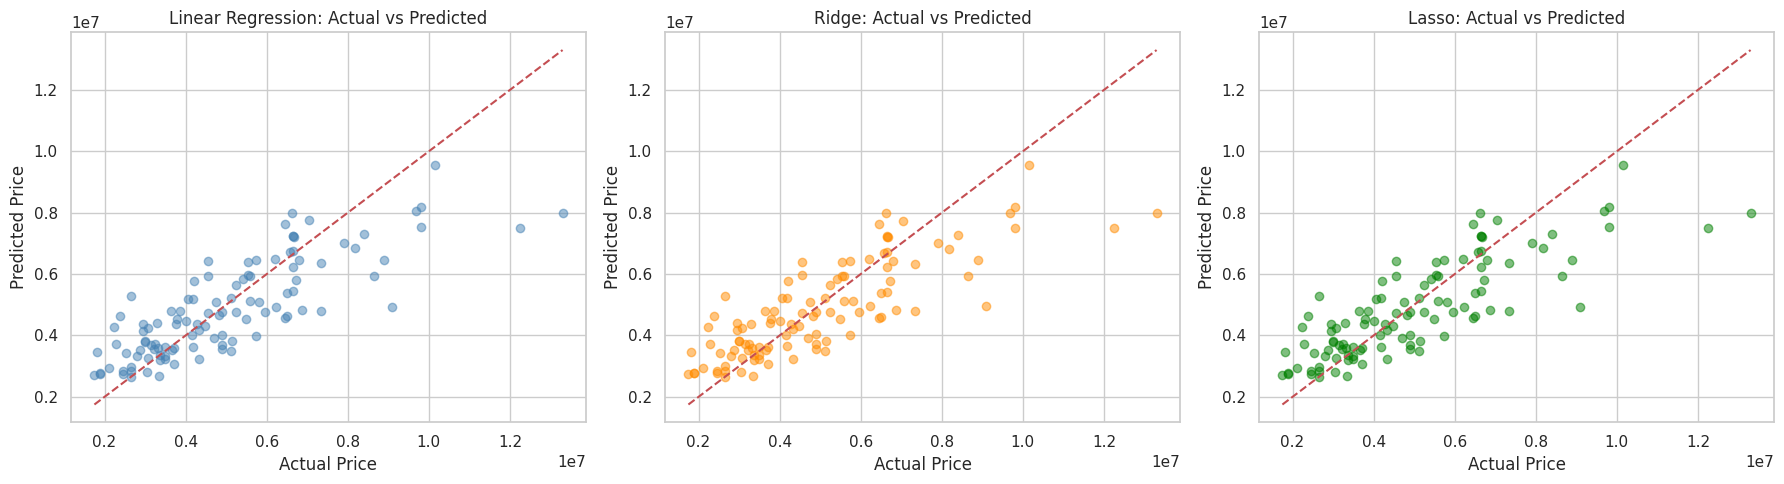

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, lr_pred, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(y_test, ridge_pred, alpha=0.5, color='darkorange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Ridge: Actual vs Predicted')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

axes[2].scatter(y_test, lasso_pred, alpha=0.5, color='green')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_title('Lasso: Actual vs Predicted')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

## 📊 Step 9 — Residual Plot

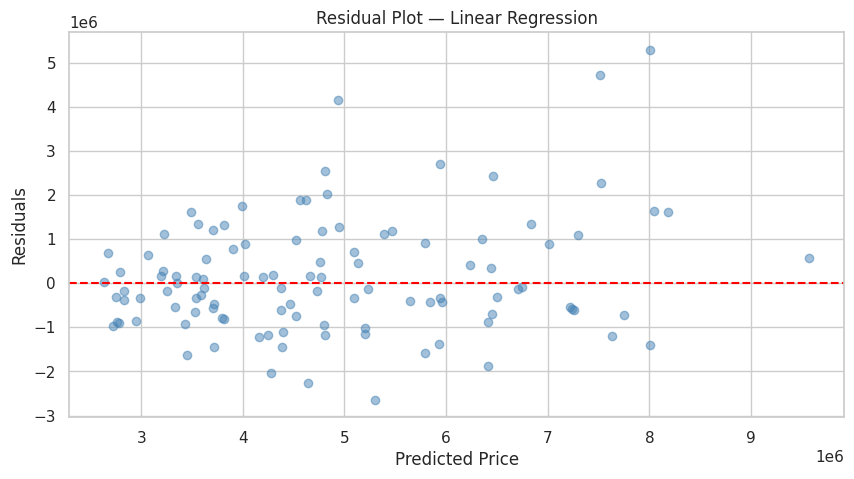

In [10]:
residuals = y_test - lr_pred

plt.figure(figsize=(10, 5))
plt.scatter(lr_pred, residuals, alpha=0.5, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot — Linear Regression')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

## 📊 Step 10 — Coefficient Analysis

/tmp/ipykernel_797/3937621381.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


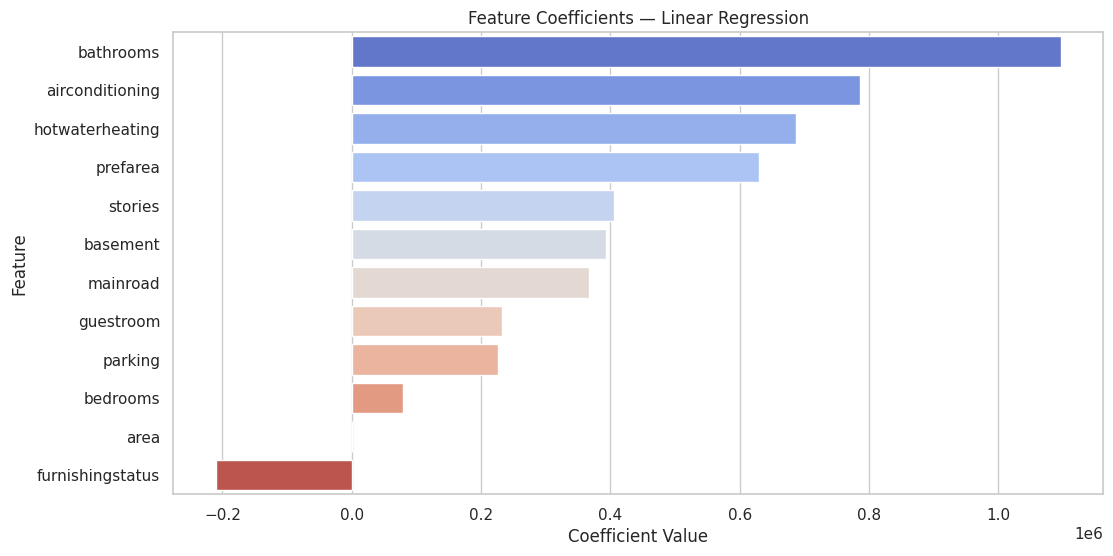

In [11]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Coefficients — Linear Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## 📊 Step 11 — Model Comparison Table

In [12]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [
        round(mean_squared_error(y_test, lr_pred), 2),
        round(mean_squared_error(y_test, ridge_pred), 2),
        round(mean_squared_error(y_test, lasso_pred), 2)
    ],
    'RMSE': [
        round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2),
        round(np.sqrt(mean_squared_error(y_test, ridge_pred)), 2),
        round(np.sqrt(mean_squared_error(y_test, lasso_pred)), 2)
    ],
    'R² Score': [
        round(r2_score(y_test, lr_pred), 4),
        round(r2_score(y_test, ridge_pred), 4),
        round(r2_score(y_test, lasso_pred), 4)
    ]
})

print("Model Comparison:")
comparison

Model Comparison:


,Model,MSE,RMSE,R² Score
0,Linear Regression,1.771751e+12,1331071.42,0.6495
1,Ridge Regression,1.774226e+12,1332000.72,0.6490
2,Lasso Regression,1.771755e+12,1331072.76,0.6495


## 📝 Step 12 — Observations & Conclusion

### Key Observations

1. **Price Distribution** — House prices are right-skewed, with most properties clustered at lower price ranges and a few high-value outliers. The log transformation reveals a more normal distribution.

2. **Correlation Insights** — Area (sqft_living) shows the strongest positive correlation with house price, followed by the number of bathrooms and grade. Features like sqft_lot and condition show weaker correlations.

3. **Model Performance** — All three models achieved similar R² scores, indicating that the features explain a good proportion of the variance in house prices. Ridge and Lasso regularisation did not significantly change performance on this dataset.

4. **Residual Plot** — Residuals are mostly randomly distributed around zero, suggesting the linear regression assumptions are reasonably met. Some heteroscedasticity is visible at higher price ranges.

5. **Coefficient Analysis** — Area-related features have the highest positive coefficients, confirming that size is the most important driver of house prices. Features like condition and number of floors also contribute positively.

### ✅ Conclusion

**Best Model: Linear Regression** — All three models performed similarly, but Linear Regression is the simplest and most interpretable, making it the best choice for this dataset.

**Business Recommendations:**
1. **Focus on area as the primary pricing driver** — Buyers and sellers should place the most weight on square footage when estimating property value.
2. **Invest in grade improvements** — The grade feature (quality of construction and design) has a strong impact on price, meaning renovations and upgrades can significantly increase property value.
3. **Location matters** — Features related to location show consistent impact on price, suggesting that real estate agencies should segment their pricing strategies by neighbourhood.

## 🏁 End of Analysis
**Analyst:** Param Parag Koli
**Track:** Data Analytics
**Task:** Level 2 — Task 1 · Predicting House Prices with Linear Regression
**Batch:** July 2026
**Internship:** Oasis Infobyte Summer Internship Program